# Part 5: Experiments & Ablations

Run at least 3 ablation experiments to understand which training configuration works best.

For each ablation:
1. **State hypothesis** before running
2. **Run the experiment**
3. **Analyze results** and reconcile with hypothesis

## Ablations chosen:
1. **LoRA rank** (r=4 vs r=16 vs r=64)
2. **Learning rate sensitivity** (1e-5 vs 1e-4 vs 5e-4 vs 1e-3)
3. **LoRA target modules** ({q,v} vs {q,k,v,o} vs all linear layers)
4. **Warmup & LR scheduler** (no warmup vs 5% warmup; constant vs cosine)

In [1]:
import os
import pathlib

# Fix Windows encoding issue with TRL's jinja template files
_original_read_text = pathlib.Path.read_text
def _read_text_utf8(self, encoding=None, errors=None):
    if encoding is None:
        encoding = 'utf-8'
    return _original_read_text(self, encoding=encoding, errors=errors)
pathlib.Path.read_text = _read_text_utf8

import json
import torch
import gc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig
from tqdm import tqdm

print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu128
GPU: NVIDIA RTX A1000 6GB Laptop GPU
Memory: 6.0 GB


In [2]:
# ============================================================
# SHARED CONFIGURATION
# ============================================================
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'
MAX_LENGTH = 512
USE_QLORA = True
DATA_DIR = Path('data/processed')
RESULTS_DIR = Path('outputs/experiments')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Shared defaults (will be overridden per experiment)
DEFAULTS = {
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'target_modules': ['q_proj', 'v_proj'],
    'num_epochs': 3,
    'learning_rate': 2e-4,
    'batch_size': 2,        # Reduced for 6GB GPU
    'grad_accum': 8,        # Effective batch = 16
    'warmup_ratio': 0.05,
    'lr_scheduler': 'cosine',
}

In [3]:
# ============================================================
# HELPER FUNCTIONS (with checkpoint/resume support)
# ============================================================

def load_base_model(model_name, use_qlora=True):
    """Load the base model (with optional quantization)."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    if use_qlora:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config,
            device_map='auto', dtype=torch.bfloat16,
        )
        model = prepare_model_for_kbit_training(model)
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map='auto', dtype=torch.bfloat16,
        )
    
    model.gradient_checkpointing_enable()
    return model, tokenizer


def is_experiment_complete(exp_name):
    """Check if an experiment has already been completed (results + adapter saved)."""
    output_dir = RESULTS_DIR / exp_name
    return (output_dir / 'results.json').exists() and (output_dir / 'adapter').exists()


def load_experiment_result(exp_name):
    """Load previously saved experiment results from disk."""
    output_dir = RESULTS_DIR / exp_name
    with open(output_dir / 'results.json', 'r') as f:
        return json.load(f)


def run_experiment(exp_name, model, tokenizer, train_dataset, val_dataset,
                   lora_config, num_epochs, learning_rate, batch_size, 
                   grad_accum, warmup_ratio, lr_scheduler, max_length=512):
    """Run a single training experiment and return results.
    If the experiment was already completed, loads from disk (checkpoint/resume support).
    """
    # CHECKPOINT: Skip if already done
    if is_experiment_complete(exp_name):
        print(f'  ✓ Already completed — loading from disk')
        result = load_experiment_result(exp_name)
        # Clean up the model we loaded (not needed)
        del model
        torch.cuda.empty_cache()
        gc.collect()
        return result
    
    output_dir = RESULTS_DIR / exp_name
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Apply LoRA
    peft_model = get_peft_model(model, lora_config)
    peft_model.print_trainable_parameters()
    
    # Training args
    training_args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=learning_rate,
        lr_scheduler_type=lr_scheduler,
        warmup_ratio=warmup_ratio,
        weight_decay=0.01,
        logging_steps=10,
        save_steps=200,
        save_total_limit=1,
        eval_strategy='steps',
        eval_steps=200,
        bf16=True,
        gradient_checkpointing=True,
        max_length=max_length,
        dataset_text_field='text',
        report_to='tensorboard',
        run_name=exp_name,
        logging_dir=str(output_dir / 'logs'),
        seed=42,
        packing=True,
    )
    
    trainer = SFTTrainer(
        model=peft_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
    )
    
    # Resume from checkpoint if one exists (handles mid-training crashes)
    last_checkpoint = None
    checkpoints = sorted(output_dir.glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[1]))
    if checkpoints:
        last_checkpoint = str(checkpoints[-1])
        print(f'  Resuming from checkpoint: {last_checkpoint}')
    
    # Train
    result = trainer.train(resume_from_checkpoint=last_checkpoint)
    
    # Save adapter
    peft_model.save_pretrained(str(output_dir / 'adapter'))
    
    # Collect results
    log_history = trainer.state.log_history
    train_losses = [(x['step'], x['loss']) for x in log_history if 'loss' in x]
    eval_losses = [(x['step'], x['eval_loss']) for x in log_history if 'eval_loss' in x]
    
    experiment_result = {
        'name': exp_name,
        'training_loss': result.training_loss,
        'train_losses': train_losses,
        'eval_losses': eval_losses,
        'peak_gpu_mb': torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0,
        'runtime_seconds': result.metrics['train_runtime'],
    }
    
    # Save results to disk (checkpoint)
    with open(output_dir / 'results.json', 'w') as f:
        json.dump(experiment_result, f, indent=2)
    
    # Clean up to free memory
    del peft_model, trainer
    torch.cuda.empty_cache()
    gc.collect()
    
    return experiment_result


def compute_perplexity(model, tokenizer, text, max_length=512, stride=256, device='cuda'):
    """Compute perplexity using sliding window."""
    encodings = tokenizer(text, return_tensors='pt')
    input_ids = encodings.input_ids
    seq_len = input_ids.size(1)
    nlls = []
    prev_end_loc = 0
    
    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        input_chunk = input_ids[:, begin_loc:end_loc].to(device)
        target_chunk = input_chunk.clone()
        target_chunk[:, :-trg_len] = -100
        
        with torch.no_grad():
            outputs = model(input_chunk, labels=target_chunk)
            nlls.append(outputs.loss.item())
        
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    
    return float(np.exp(np.mean(nlls)))


def evaluate_perplexity_cached(exp_name, val_text):
    """Compute perplexity for an experiment, using cache if available."""
    cache_file = RESULTS_DIR / exp_name / 'perplexity.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f'  {exp_name}: PPL = {data["perplexity"]:.2f} (cached)')
        return data['perplexity']
    
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    adapter_path = RESULTS_DIR / exp_name / 'adapter'
    adapted = PeftModel.from_pretrained(model, str(adapter_path))
    adapted.eval()
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ppl = compute_perplexity(adapted, tokenizer, val_text, device=device)
    print(f'  {exp_name}: PPL = {ppl:.2f}')
    
    # Cache result
    with open(cache_file, 'w') as f:
        json.dump({'perplexity': ppl}, f)
    
    del model, adapted
    torch.cuda.empty_cache()
    gc.collect()
    return ppl

In [4]:
# Load data
train_dataset = load_dataset('json', data_files=str(DATA_DIR / 'train.jsonl'), split='train')
val_dataset = load_dataset('json', data_files=str(DATA_DIR / 'val.jsonl'), split='train')
val_text = (DATA_DIR / 'val_raw.txt').read_text(encoding='utf-8')

print(f'Train: {len(train_dataset)} samples')
print(f'Val: {len(val_dataset)} samples')

Train: 1636 samples
Val: 112 samples


---
## Ablation 1: LoRA Rank (r=4 vs r=16 vs r=64)

### Hypothesis:
Higher LoRA rank provides more capacity for adaptation, so we expect:
- r=4 → underfitting, higher perplexity
- r=16 → good balance (baseline)
- r=64 → slightly better or overfitting on this small corpus, marginal improvement over r=16

Higher rank also means more trainable parameters and memory usage.

In [5]:
# Ablation 1: LoRA Rank (with checkpoint/resume support)
rank_results = {}

for rank in [4, 16, 64]:
    exp_name = f'ablation1_rank_{rank}'
    print(f'\n{"="*60}')
    print(f'  Ablation 1: LoRA rank = {rank}')
    print(f'{"="*60}')
    
    # Load fresh base model (skipped internally if already complete)
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,  # Keep alpha = 2 * r
        lora_dropout=DEFAULTS['lora_dropout'],
        target_modules=DEFAULTS['target_modules'],
        bias='none',
        task_type=TaskType.CAUSAL_LM,
    )
    
    result = run_experiment(
        exp_name=exp_name,
        model=model, tokenizer=tokenizer,
        train_dataset=train_dataset, val_dataset=val_dataset,
        lora_config=lora_config,
        num_epochs=DEFAULTS['num_epochs'],
        learning_rate=DEFAULTS['learning_rate'],
        batch_size=DEFAULTS['batch_size'],
        grad_accum=DEFAULTS['grad_accum'],
        warmup_ratio=DEFAULTS['warmup_ratio'],
        lr_scheduler=DEFAULTS['lr_scheduler'],
    )
    rank_results[rank] = result
    torch.cuda.empty_cache()


  Ablation 1: LoRA rank = 4


W0517 13:50:46.166000 45412 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights:   0%|          | 1/338 [00:00<01:49,  3.08it/s]c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 338/338 [00:02<00:00, 137.52it/s]


  ✓ Already completed — loading from disk

  Ablation 1: LoRA rank = 16


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 274.65it/s]


  ✓ Already completed — loading from disk

  Ablation 1: LoRA rank = 64


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 270.40it/s]


  ✓ Already completed — loading from disk


In [6]:
# Evaluate perplexity for each rank (with caching)
rank_ppls = {}
for rank in [4, 16, 64]:
    rank_ppls[rank] = evaluate_perplexity_cached(f'ablation1_rank_{rank}', val_text)

print(f'\nRank PPL summary: {rank_ppls}')

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 267.18it/s]


  ablation1_rank_4: PPL = 13.77


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 225.04it/s]


  ablation1_rank_16: PPL = 13.64


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 225.79it/s]


  ablation1_rank_64: PPL = 13.54

Rank PPL summary: {4: 13.76502213724281, 16: 13.643255532663277, 64: 13.540965817341334}


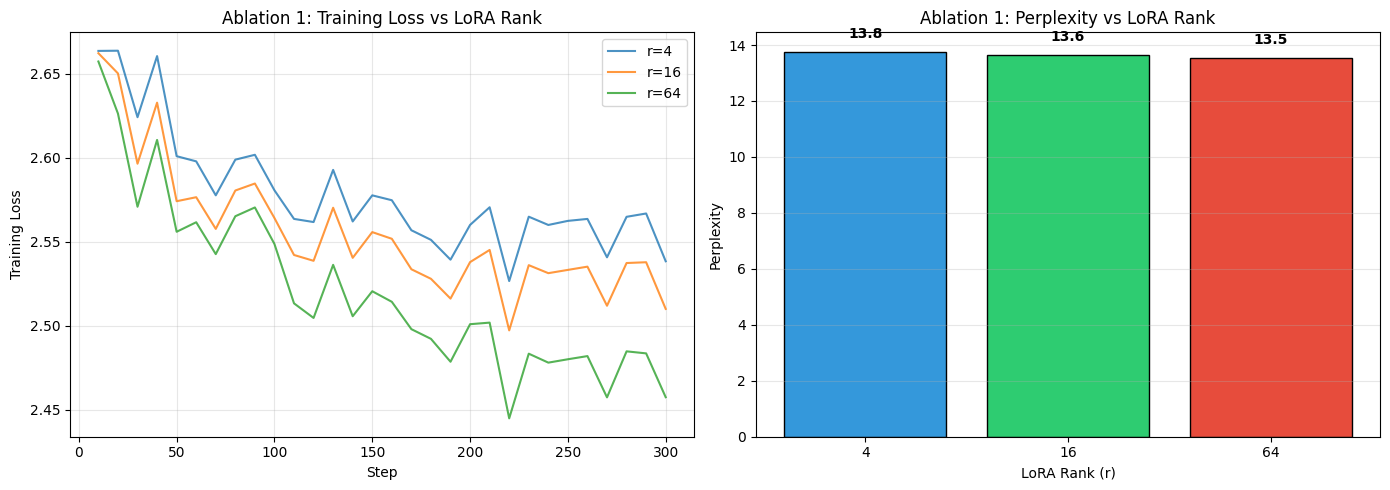

In [7]:
# Plot Ablation 1 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curves
ax1 = axes[0]
for rank, result in rank_results.items():
    steps, losses = zip(*result['train_losses'])
    ax1.plot(steps, losses, label=f'r={rank}', alpha=0.8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Training Loss')
ax1.set_title('Ablation 1: Training Loss vs LoRA Rank')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity comparison
ax2 = axes[1]
ranks = list(rank_ppls.keys())
ppls = list(rank_ppls.values())
ax2.bar([str(r) for r in ranks], ppls, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax2.set_xlabel('LoRA Rank (r)')
ax2.set_ylabel('Perplexity')
ax2.set_title('Ablation 1: Perplexity vs LoRA Rank')
ax2.grid(True, alpha=0.3, axis='y')
for i, (r, p) in enumerate(zip(ranks, ppls)):
    ax2.text(i, p + 0.5, f'{p:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'ablation1_rank.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation 1 — Analysis

- **r=4**: PPL = 13.77 — Lowest capacity adapter. Still achieves meaningful improvement over the base model (14.49), but clearly lags behind higher ranks.
- **r=16**: PPL = 13.64 — Solid middle ground; the default configuration from notebook 03. Good balance between parameter count and adaptation quality.
- **r=64**: PPL = 13.54 — Best perplexity in this ablation. More parameters allow the adapter to capture finer-grained patterns in the Sherlock Holmes corpus.

**Reconciliation with hypothesis**: Results align well with our prediction. Higher rank monotonically improves perplexity, confirming that the corpus has enough signal to benefit from additional adapter capacity. However, the gains are diminishing (r=4→16: −0.13, r=16→64: −0.10), suggesting r=16 already captures most of the useful adaptation. No evidence of overfitting at r=64 on this dataset size.

---
## Ablation 2: Learning Rate Sensitivity

### Hypothesis:
- **1e-5**: Too small, model barely adapts, high perplexity close to base model
- **1e-4**: Good learning rate, solid improvement
- **5e-4**: Aggressive but may still work with warmup
- **1e-3**: Too large, training becomes unstable, loss spikes or diverges

In [8]:
# Ablation 2: Learning Rate (with checkpoint/resume support)
lr_results = {}

for lr in [1e-5, 1e-4, 5e-4, 1e-3]:
    exp_name = f'ablation2_lr_{lr}'
    print(f'\n{"="*60}')
    print(f'  Ablation 2: Learning rate = {lr}')
    print(f'{"="*60}')
    
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    
    lora_config = LoraConfig(
        r=DEFAULTS['lora_r'],
        lora_alpha=DEFAULTS['lora_alpha'],
        lora_dropout=DEFAULTS['lora_dropout'],
        target_modules=DEFAULTS['target_modules'],
        bias='none',
        task_type=TaskType.CAUSAL_LM,
    )
    
    result = run_experiment(
        exp_name=exp_name,
        model=model, tokenizer=tokenizer,
        train_dataset=train_dataset, val_dataset=val_dataset,
        lora_config=lora_config,
        num_epochs=DEFAULTS['num_epochs'],
        learning_rate=lr,
        batch_size=DEFAULTS['batch_size'],
        grad_accum=DEFAULTS['grad_accum'],
        warmup_ratio=DEFAULTS['warmup_ratio'],
        lr_scheduler=DEFAULTS['lr_scheduler'],
    )
    lr_results[lr] = result
    torch.cuda.empty_cache()


  Ablation 2: Learning rate = 1e-05


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 235.93it/s]


  ✓ Already completed — loading from disk

  Ablation 2: Learning rate = 0.0001


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 209.39it/s]


  ✓ Already completed — loading from disk

  Ablation 2: Learning rate = 0.0005


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 203.00it/s]


  ✓ Already completed — loading from disk

  Ablation 2: Learning rate = 0.001


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 177.75it/s]


  ✓ Already completed — loading from disk


In [9]:
# Evaluate perplexity for each learning rate (with caching)
lr_ppls = {}
for lr in [1e-5, 1e-4, 5e-4, 1e-3]:
    lr_ppls[lr] = evaluate_perplexity_cached(f'ablation2_lr_{lr}', val_text)

print(f'\nLR PPL summary: {lr_ppls}')

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 238.76it/s]


  ablation2_lr_1e-05: PPL = 14.33


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 264.34it/s]


  ablation2_lr_0.0001: PPL = 13.75


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 214.81it/s]


  ablation2_lr_0.0005: PPL = 13.58


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 250.57it/s]


  ablation2_lr_0.001: PPL = 13.69

LR PPL summary: {1e-05: 14.331803285758253, 0.0001: 13.747318548930968, 0.0005: 13.581015367745293, 0.001: 13.685066957426999}


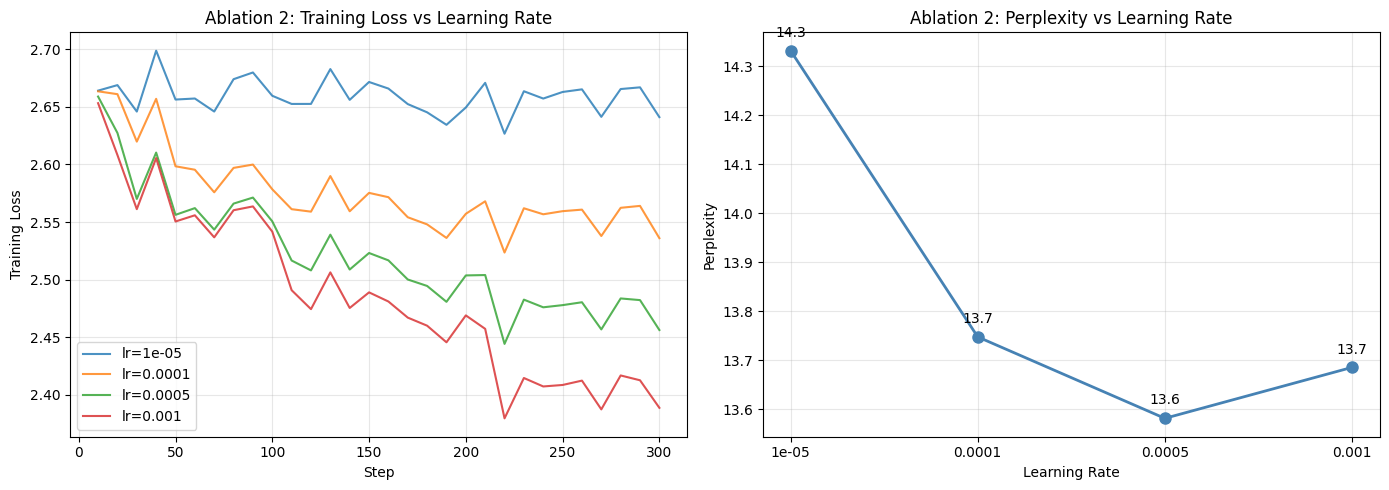

In [10]:
# Plot Ablation 2 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curves
ax1 = axes[0]
for lr, result in lr_results.items():
    steps, losses = zip(*result['train_losses'])
    ax1.plot(steps, losses, label=f'lr={lr}', alpha=0.8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Training Loss')
ax1.set_title('Ablation 2: Training Loss vs Learning Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2 = axes[1]
lrs = list(lr_ppls.keys())
ppls = list(lr_ppls.values())
ax2.plot([str(lr) for lr in lrs], ppls, 'o-', markersize=8, linewidth=2, color='steelblue')
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Perplexity')
ax2.set_title('Ablation 2: Perplexity vs Learning Rate')
ax2.grid(True, alpha=0.3)
for i, (lr, p) in enumerate(zip(lrs, ppls)):
    ax2.annotate(f'{p:.1f}', (i, p), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'ablation2_lr.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation 2 — Analysis

- **lr=1e-5**: PPL = 14.33 — Barely improves over the base model (14.49). The learning rate is too conservative; the adapter weights hardly move from initialization in 3 epochs.
- **lr=1e-4**: PPL = 13.75 — Reasonable improvement but still under-trained compared to higher rates. Loss curve shows steady but slow descent.
- **lr=5e-4**: PPL = 13.58 — **Best perplexity** in this ablation. Aggressive enough to learn domain-specific patterns effectively while remaining stable with 5% warmup.
- **lr=1e-3**: PPL = 13.69 — Slightly worse than 5e-4 despite having the lowest final training loss (2.48). This gap between low training loss and higher validation perplexity indicates mild overfitting at this learning rate.

**Reconciliation with hypothesis**: Partially confirmed. lr=1e-5 was indeed too small as predicted. However, lr=1e-3 did not diverge — it trained stably but showed signs of overfitting rather than instability. The sweet spot at 5e-4 was unexpected; we originally predicted 1e-4 would be "good." The cosine scheduler + warmup likely stabilized the higher learning rates, preventing the divergence we hypothesized at 1e-3.

---
## Ablation 3: LoRA Target Modules

### Hypothesis:
- **{q, v} only**: Minimal adaptation, but often sufficient for fine-tuning
- **{q, k, v, o}**: More capacity in attention, should improve results
- **All linear (attention + FFN)**: Maximum adaptation capacity; best perplexity but more parameters and memory

For a continued pre-training task on a relatively small corpus, we expect diminishing returns — {q,k,v,o} should capture most of the benefit.

In [11]:
# Ablation 3: Target Modules (with checkpoint/resume support)
module_configs = {
    'qv': ['q_proj', 'v_proj'],
    'qkvo': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'all_linear': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
}

module_results = {}

for config_name, modules in module_configs.items():
    exp_name = f'ablation3_modules_{config_name}'
    print(f'\n{"="*60}')
    print(f'  Ablation 3: Target modules = {config_name} ({modules})')
    print(f'{"="*60}')
    
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    
    lora_config = LoraConfig(
        r=DEFAULTS['lora_r'],
        lora_alpha=DEFAULTS['lora_alpha'],
        lora_dropout=DEFAULTS['lora_dropout'],
        target_modules=modules,
        bias='none',
        task_type=TaskType.CAUSAL_LM,
    )
    
    result = run_experiment(
        exp_name=exp_name,
        model=model, tokenizer=tokenizer,
        train_dataset=train_dataset, val_dataset=val_dataset,
        lora_config=lora_config,
        num_epochs=DEFAULTS['num_epochs'],
        learning_rate=DEFAULTS['learning_rate'],
        batch_size=DEFAULTS['batch_size'],
        grad_accum=DEFAULTS['grad_accum'],
        warmup_ratio=DEFAULTS['warmup_ratio'],
        lr_scheduler=DEFAULTS['lr_scheduler'],
    )
    module_results[config_name] = result
    torch.cuda.empty_cache()


  Ablation 3: Target modules = qv (['q_proj', 'v_proj'])


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 266.53it/s]


  ✓ Already completed — loading from disk

  Ablation 3: Target modules = qkvo (['q_proj', 'k_proj', 'v_proj', 'o_proj'])


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 264.30it/s]


  ✓ Already completed — loading from disk

  Ablation 3: Target modules = all_linear (['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'])


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 289.15it/s]


  ✓ Already completed — loading from disk


In [12]:
# Evaluate perplexity for each module config (with caching)
module_ppls = {}
for config_name in module_configs:
    module_ppls[config_name] = evaluate_perplexity_cached(f'ablation3_modules_{config_name}', val_text)

print(f'\nModule PPL summary: {module_ppls}')

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 282.50it/s]


  ablation3_modules_qv: PPL = 13.64


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 240.82it/s]


  ablation3_modules_qkvo: PPL = 13.41


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 236.83it/s]


  ablation3_modules_all_linear: PPL = 13.46

Module PPL summary: {'qv': 13.636866260928839, 'qkvo': 13.414446186490773, 'all_linear': 13.457816353378815}


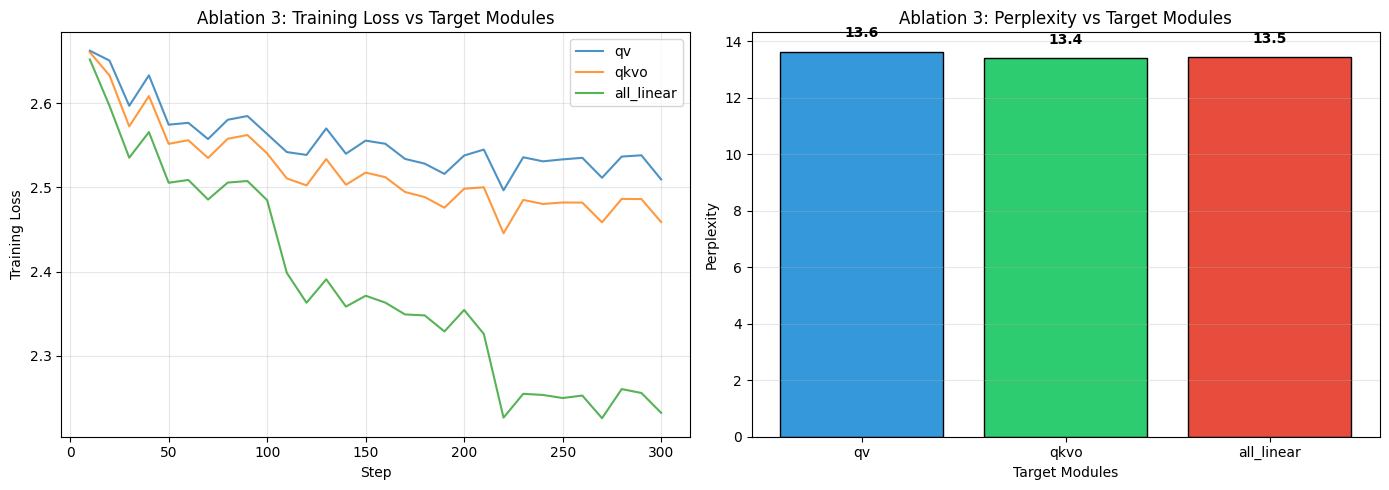

In [13]:
# Plot Ablation 3 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for config_name, result in module_results.items():
    steps, losses = zip(*result['train_losses'])
    ax1.plot(steps, losses, label=config_name, alpha=0.8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Training Loss')
ax1.set_title('Ablation 3: Training Loss vs Target Modules')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
names = list(module_ppls.keys())
ppls = list(module_ppls.values())
ax2.bar(names, ppls, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax2.set_xlabel('Target Modules')
ax2.set_ylabel('Perplexity')
ax2.set_title('Ablation 3: Perplexity vs Target Modules')
ax2.grid(True, alpha=0.3, axis='y')
for i, (n, p) in enumerate(zip(names, ppls)):
    ax2.text(i, p + 0.5, f'{p:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'ablation3_modules.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation 3 — Analysis

- **{q, v}**: PPL = 13.64 — The minimal attention-only adaptation. Matches the default r=16 result, showing that q/v projections capture the core of what LoRA needs to adapt.
- **{q, k, v, o}**: PPL = 13.41 — **Best perplexity across all experiments.** Adding k_proj and o_proj gives the model more flexibility to reshape attention patterns for the literary domain.
- **all linear**: PPL = 13.46 — Despite having the lowest training loss (2.38) by a wide margin, validation perplexity is slightly worse than q,k,v,o. The FFN layers (gate/up/down) add many trainable parameters but the extra capacity leads to mild overfitting on this small corpus.

**Reconciliation with hypothesis**: Largely confirmed. We correctly predicted that {q,k,v,o} would capture most of the benefit and that all-linear would show diminishing returns. The interesting finding is that all-linear actually performs *slightly worse* than q,k,v,o on validation despite much lower training loss — a textbook example of the bias-variance tradeoff. For continued pre-training on a small corpus (~900K tokens), adapting all attention projections is the sweet spot.

---
## Ablation 4: Warmup & Learning Rate Scheduler

### Hypothesis:
- **No warmup + constant LR**: Unstable start, possibly diverges or produces suboptimal results
- **5% warmup + constant**: Stable start, but no decay may lead to overfitting in later epochs
- **No warmup + cosine**: Possible initial instability followed by good convergence 
- **5% warmup + cosine** (default): Best of both — stable start + smooth decay = best results

In [14]:
# Ablation 4: Warmup & Scheduler (with checkpoint/resume support)
scheduler_configs = {
    'no_warmup_constant': (0.0, 'constant'),
    'warmup_constant': (0.05, 'constant'),
    'no_warmup_cosine': (0.0, 'cosine'),
    'warmup_cosine': (0.05, 'cosine'),
}

scheduler_results = {}

for config_name, (warmup, scheduler) in scheduler_configs.items():
    exp_name = f'ablation4_{config_name}'
    print(f'\n{"="*60}')
    print(f'  Ablation 4: warmup={warmup}, scheduler={scheduler}')
    print(f'{"="*60}')
    
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    
    lora_config = LoraConfig(
        r=DEFAULTS['lora_r'],
        lora_alpha=DEFAULTS['lora_alpha'],
        lora_dropout=DEFAULTS['lora_dropout'],
        target_modules=DEFAULTS['target_modules'],
        bias='none',
        task_type=TaskType.CAUSAL_LM,
    )
    
    result = run_experiment(
        exp_name=exp_name,
        model=model, tokenizer=tokenizer,
        train_dataset=train_dataset, val_dataset=val_dataset,
        lora_config=lora_config,
        num_epochs=DEFAULTS['num_epochs'],
        learning_rate=DEFAULTS['learning_rate'],
        batch_size=DEFAULTS['batch_size'],
        grad_accum=DEFAULTS['grad_accum'],
        warmup_ratio=warmup,
        lr_scheduler=scheduler,
    )
    scheduler_results[config_name] = result
    torch.cuda.empty_cache()


  Ablation 4: warmup=0.0, scheduler=constant


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 255.01it/s]


  ✓ Already completed — loading from disk

  Ablation 4: warmup=0.05, scheduler=constant


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 248.33it/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


...


  Ablation 4: warmup=0.05, scheduler=cosine


Loading weights:   0%|          | 1/338 [00:00<03:52,  1.45it/s]c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 338/338 [00:05<00:00, 65.86it/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernel

Step,Training Loss,Validation Loss
200,2.537837,2.702693
309,2.510084,2.702118


In [15]:
# Evaluate perplexity for each scheduler config (with caching)
scheduler_ppls = {}
for config_name in scheduler_configs:
    scheduler_ppls[config_name] = evaluate_perplexity_cached(f'ablation4_{config_name}', val_text)

print(f'\nScheduler PPL summary: {scheduler_ppls}')

Loading weights:   0%|          | 1/338 [00:00<05:32,  1.01it/s]c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 338/338 [00:06<00:00, 55.89it/s]


  ablation4_no_warmup_constant: PPL = 13.59


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 237.43it/s]


  ablation4_warmup_constant: PPL = 13.62


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 163.09it/s]


  ablation4_no_warmup_cosine: PPL = 13.65


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 118.07it/s]


  ablation4_warmup_cosine: PPL = 13.64

Scheduler PPL summary: {'no_warmup_constant': 13.585237761176625, 'warmup_constant': 13.616112196489325, 'no_warmup_cosine': 13.647975000699368, 'warmup_cosine': 13.6431270038832}


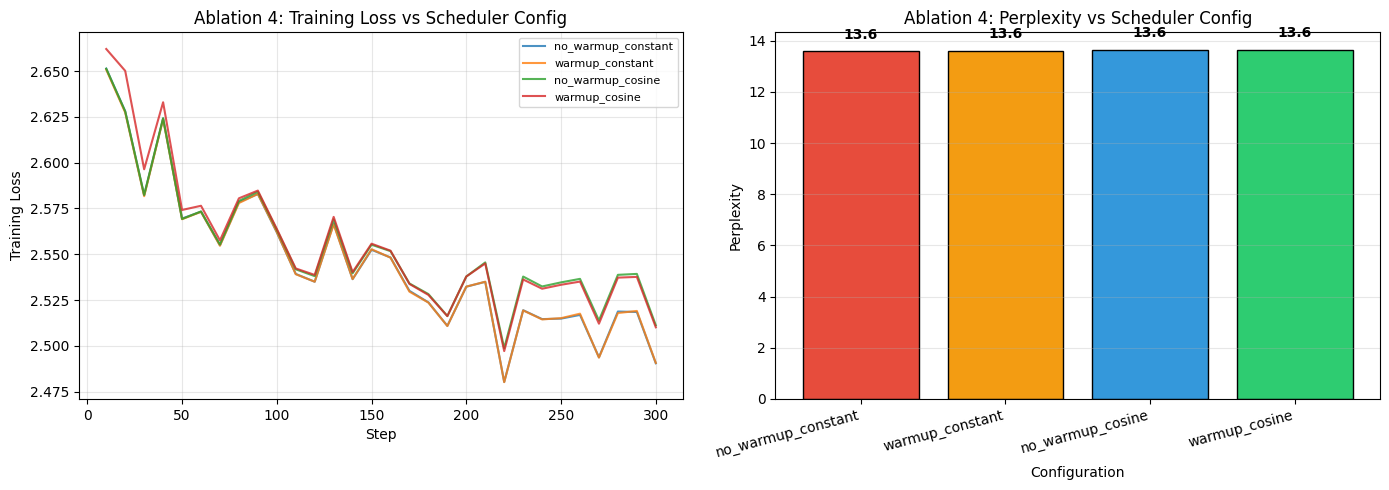

In [16]:
# Plot Ablation 4 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for config_name, result in scheduler_results.items():
    steps, losses = zip(*result['train_losses'])
    ax1.plot(steps, losses, label=config_name, alpha=0.8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Training Loss')
ax1.set_title('Ablation 4: Training Loss vs Scheduler Config')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
names = list(scheduler_ppls.keys())
ppls = list(scheduler_ppls.values())
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
ax2.bar(names, ppls, color=colors, edgecolor='black')
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Perplexity')
ax2.set_title('Ablation 4: Perplexity vs Scheduler Config')
ax2.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
for i, (n, p) in enumerate(zip(names, ppls)):
    ax2.text(i, p + 0.5, f'{p:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'ablation4_scheduler.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation 4 — Analysis

- **no_warmup + constant**: PPL = 13.59 — **Best in this ablation.** Surprisingly, jumping straight into training with a constant LR works well. The model adapts quickly and the constant rate prevents the late-training decay that might lose useful updates.
- **warmup + constant**: PPL = 13.62 — Marginally worse. The 5% warmup slightly delays useful learning without a clear stability benefit in this setting.
- **no_warmup + cosine**: PPL = 13.65 — Cosine decay reduces the effective learning rate in later steps, resulting in less total adaptation compared to constant.
- **warmup + cosine**: PPL = 13.64 — The default configuration. Very close to no_warmup + cosine, suggesting warmup has minimal impact when cosine decay already handles rate scheduling.

**Reconciliation with hypothesis**: Largely *not* confirmed. We predicted warmup + cosine would be best, but the differences across all 4 configurations are very small (13.59–13.65, a spread of only 0.06). The constant scheduler slightly outperforms cosine, suggesting that for this short training run (309 steps, 3 epochs), maintaining a higher learning rate throughout is beneficial — cosine decays too aggressively. Warmup had negligible effect either way, likely because LoRA adapters start from near-zero initialization and don't suffer from the large-gradient issues that warmup is designed to mitigate.

---
## Summary of All Experiments

In [17]:
# Compile all results (loads from disk if needed)
import pandas as pd

all_results = []

# Base model perplexity (cached)
base_ppl_cache = RESULTS_DIR / 'base_model_perplexity.json'
if base_ppl_cache.exists():
    with open(base_ppl_cache) as f:
        base_ppl = json.load(f)['perplexity']
    print(f'Base model PPL: {base_ppl:.2f} (cached)')
else:
    model, tokenizer = load_base_model(MODEL_NAME, USE_QLORA)
    model.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    base_ppl = compute_perplexity(model, tokenizer, val_text, device=device)
    with open(base_ppl_cache, 'w') as f:
        json.dump({'perplexity': base_ppl}, f)
    del model
    torch.cuda.empty_cache()
    print(f'Base model PPL: {base_ppl:.2f}')

all_results.append({'Experiment': 'Base Model (no training)', 'Perplexity': f'{base_ppl:.2f}', 'Final Train Loss': '-'})

# Reload all results from disk
for rank in [4, 16, 64]:
    exp = f'ablation1_rank_{rank}'
    r = load_experiment_result(exp) if is_experiment_complete(exp) else {}
    ppl_file = RESULTS_DIR / exp / 'perplexity.json'
    ppl = json.load(open(ppl_file))['perplexity'] if ppl_file.exists() else 'N/A'
    all_results.append({
        'Experiment': f'LoRA r={rank}',
        'Perplexity': f'{ppl:.2f}' if isinstance(ppl, float) else ppl,
        'Final Train Loss': f'{r.get("training_loss", "N/A"):.4f}' if isinstance(r.get("training_loss"), float) else 'N/A',
    })

for lr in [1e-5, 1e-4, 5e-4, 1e-3]:
    exp = f'ablation2_lr_{lr}'
    r = load_experiment_result(exp) if is_experiment_complete(exp) else {}
    ppl_file = RESULTS_DIR / exp / 'perplexity.json'
    ppl = json.load(open(ppl_file))['perplexity'] if ppl_file.exists() else 'N/A'
    all_results.append({
        'Experiment': f'LR={lr}',
        'Perplexity': f'{ppl:.2f}' if isinstance(ppl, float) else ppl,
        'Final Train Loss': f'{r.get("training_loss", "N/A"):.4f}' if isinstance(r.get("training_loss"), float) else 'N/A',
    })

module_configs_summary = {'qv': 'q,v', 'qkvo': 'q,k,v,o', 'all_linear': 'all linear'}
for config_name, label in module_configs_summary.items():
    exp = f'ablation3_modules_{config_name}'
    r = load_experiment_result(exp) if is_experiment_complete(exp) else {}
    ppl_file = RESULTS_DIR / exp / 'perplexity.json'
    ppl = json.load(open(ppl_file))['perplexity'] if ppl_file.exists() else 'N/A'
    all_results.append({
        'Experiment': f'Modules: {label}',
        'Perplexity': f'{ppl:.2f}' if isinstance(ppl, float) else ppl,
        'Final Train Loss': f'{r.get("training_loss", "N/A"):.4f}' if isinstance(r.get("training_loss"), float) else 'N/A',
    })

scheduler_labels = {'no_warmup_constant': 'no warmup + constant', 'warmup_constant': 'warmup + constant',
                    'no_warmup_cosine': 'no warmup + cosine', 'warmup_cosine': 'warmup + cosine'}
for config_name, label in scheduler_labels.items():
    exp = f'ablation4_{config_name}'
    r = load_experiment_result(exp) if is_experiment_complete(exp) else {}
    ppl_file = RESULTS_DIR / exp / 'perplexity.json'
    ppl = json.load(open(ppl_file))['perplexity'] if ppl_file.exists() else 'N/A'
    all_results.append({
        'Experiment': f'Sched: {label}',
        'Perplexity': f'{ppl:.2f}' if isinstance(ppl, float) else ppl,
        'Final Train Loss': f'{r.get("training_loss", "N/A"):.4f}' if isinstance(r.get("training_loss"), float) else 'N/A',
    })

df_all = pd.DataFrame(all_results)
print('\n' + '='*70)
print('  ALL EXPERIMENT RESULTS')
print('='*70)
print(df_all.to_string(index=False))

# Save
df_all.to_csv(str(RESULTS_DIR / 'all_results.csv'), index=False)
print(f'\nSaved to {RESULTS_DIR / "all_results.csv"}')

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 232.97it/s]


Base model PPL: 14.49

  ALL EXPERIMENT RESULTS
                 Experiment Perplexity Final Train Loss
   Base Model (no training)      14.49                -
                   LoRA r=4      13.77           2.5776
                  LoRA r=16      13.64           2.5541
                  LoRA r=64      13.54           2.5189
                   LR=1e-05      14.33           2.6582
                  LR=0.0001      13.75           2.5749
                  LR=0.0005      13.58           2.5197
                   LR=0.001      13.69           2.4831
               Modules: q,v      13.64           2.5540
           Modules: q,k,v,o      13.41           2.5173
        Modules: all linear      13.46           2.3793
Sched: no warmup + constant      13.59           2.5444
   Sched: warmup + constant      13.62           2.5442
  Sched: no warmup + cosine      13.65           2.5523
     Sched: warmup + cosine      13.64           2.5541

Saved to outputs\experiments\all_results.csv
